In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import shap
import sys
sys.path.append('src')

freq_axis  = np.load('data/simulated_clean/freq_axis.npy')
X_test     = np.load('data/simulated_noisy/signals_noisy.npy')[850:]
y_test     = np.load('data/simulated_clean/signals.npy')[850:]
auto_out   = np.load('data/processed/autoencoder_denoised.npy')

print(f"Test noisy  : {X_test.shape}")
print(f"Test clean  : {y_test.shape}")

Test noisy  : (150, 512)
Test clean  : (150, 512)


In [2]:
class THz_Autoencoder(nn.Module):
    def __init__(self):
        super(THz_Autoencoder, self).__init__()

        self.encoder = nn.Sequential(
            nn.Conv1d(1, 16, kernel_size=7, padding=3),
            nn.ReLU(),
            nn.MaxPool1d(2),
            nn.Conv1d(16, 32, kernel_size=5, padding=2),
            nn.ReLU(),
            nn.MaxPool1d(2),
            nn.Conv1d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool1d(2),
        )

        self.decoder = nn.Sequential(
            nn.ConvTranspose1d(64, 32, kernel_size=4, stride=2, padding=1),
            nn.ReLU(),
            nn.ConvTranspose1d(32, 16, kernel_size=4, stride=2, padding=1),
            nn.ReLU(),
            nn.ConvTranspose1d(16, 1,  kernel_size=4, stride=2, padding=1),
        )

    def forward(self, x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return decoded

model = THz_Autoencoder()
model.load_state_dict(torch.load('models/autoencoder_best.pt'))
model.eval()
print("Model loaded!")

Model loaded!


In [4]:
X_tensor   = torch.tensor(X_test[:50]).unsqueeze(1).float()
background = X_tensor[:10]
test_samples = X_tensor[10:20]

class ModelWrapper(nn.Module):
    def __init__(self, model):
        super().__init__()
        self.model = model

    def forward(self, x):
        out = self.model(x)
        return out.mean(dim=2)

wrapped_model = ModelWrapper(model)
wrapped_model.eval()

explainer    = shap.GradientExplainer(wrapped_model, background)
shap_values  = explainer.shap_values(test_samples)

shap_array = np.array(shap_values).squeeze()
print(f"SHAP values shape : {shap_array.shape}")

SHAP values shape : (10, 512)


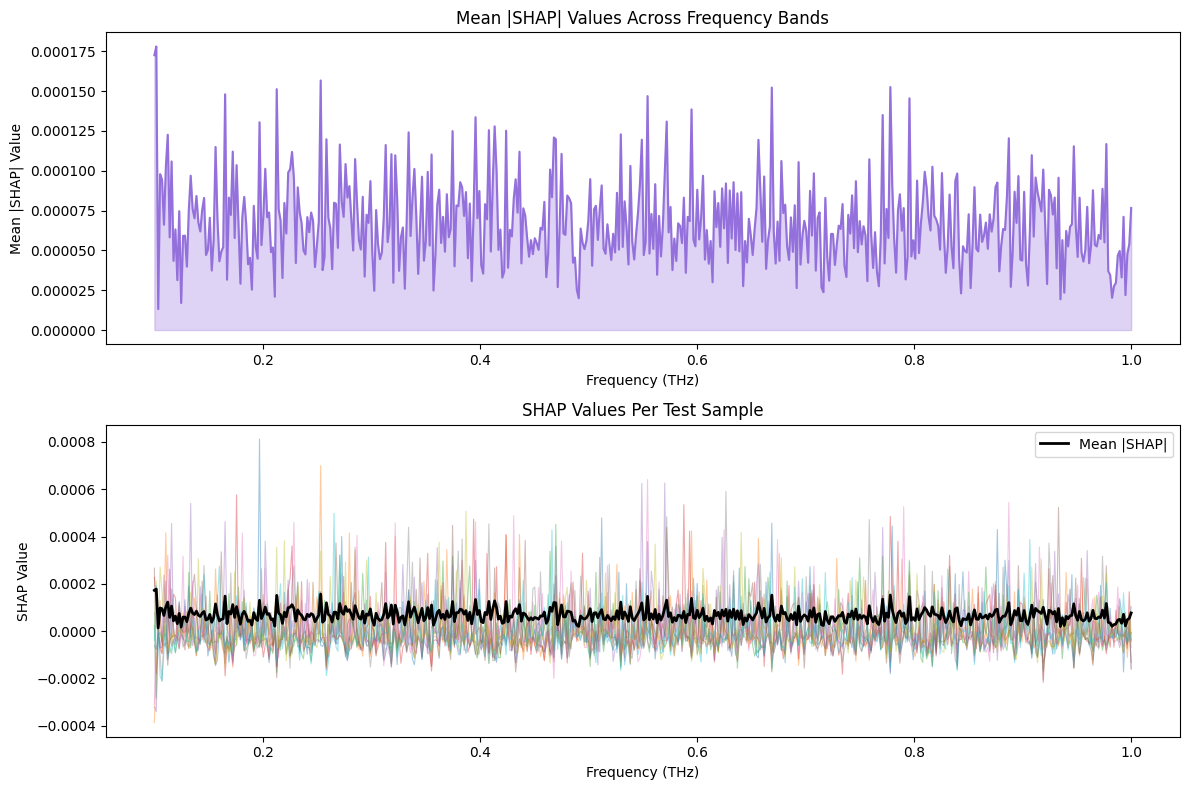

In [5]:
mean_shap = np.mean(np.abs(shap_array), axis=0)

fig, axes = plt.subplots(2, 1, figsize=(12, 8))

axes[0].plot(freq_axis, mean_shap, color='mediumpurple', linewidth=1.5)
axes[0].fill_between(freq_axis, mean_shap, alpha=0.3, color='mediumpurple')
axes[0].set_title('Mean |SHAP| Values Across Frequency Bands')
axes[0].set_xlabel('Frequency (THz)')
axes[0].set_ylabel('Mean |SHAP| Value')

for i in range(len(shap_array)):
    axes[1].plot(freq_axis, shap_array[i], alpha=0.4, linewidth=0.8)
axes[1].plot(freq_axis, mean_shap, color='black', linewidth=2, label='Mean |SHAP|')
axes[1].set_title('SHAP Values Per Test Sample')
axes[1].set_xlabel('Frequency (THz)')
axes[1].set_ylabel('SHAP Value')
axes[1].legend()

plt.tight_layout()
plt.savefig('results/figures/06_shap_frequency.png', dpi=150)
plt.show()

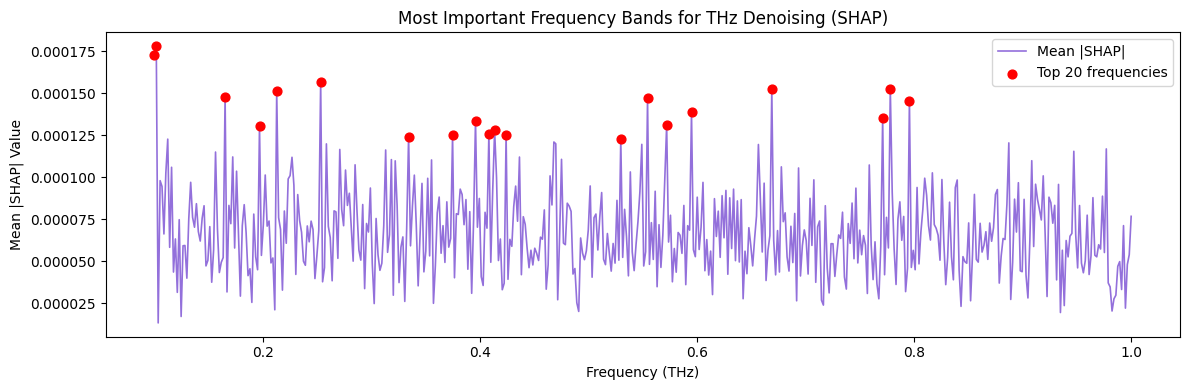

Top 20 most important frequencies (THz):
[0.1   0.102 0.165 0.197 0.213 0.253 0.334 0.375 0.396 0.408 0.414 0.424
 0.53  0.554 0.572 0.595 0.669 0.771 0.778 0.796]


In [6]:
top_indices = np.argsort(mean_shap)[-20:]
top_freqs   = freq_axis[top_indices]

plt.figure(figsize=(12, 4))
plt.plot(freq_axis, mean_shap, color='mediumpurple', linewidth=1.2, label='Mean |SHAP|')
plt.scatter(top_freqs, mean_shap[top_indices], color='red', zorder=5, s=40, label='Top 20 frequencies')
plt.title('Most Important Frequency Bands for THz Denoising (SHAP)')
plt.xlabel('Frequency (THz)')
plt.ylabel('Mean |SHAP| Value')
plt.legend()
plt.tight_layout()
plt.savefig('results/figures/06_shap_top_frequencies.png', dpi=150)
plt.show()

print("Top 20 most important frequencies (THz):")
print(np.sort(top_freqs).round(3))